In [9]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from thefuzz import fuzz

In [3]:
category_untuned = []
with open("category-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        category_untuned.append(json.loads(line))

In [4]:
category_finetuned = []
with open("category-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-category-try1:CobZKZz1.jsonl") as file:
    for line in file:
        category_finetuned.append(json.loads(line))

In [5]:
tag_untuned = []
with open("tag-gpt-4.1-mini-2025-04-14.jsonl") as file:
    for line in file:
        tag_untuned.append(json.loads(line))

In [6]:
tag_finetuned = []
with open("tag-ft:gpt-4.1-mini-2025-04-14:u-chicago:cgfp-tag-try1:CobaLhVa.jsonl") as file:
    for line in file:
        tag_finetuned.append(json.loads(line))

In [33]:
def category_to_df(data):
    df_input = []
    df_category = []
    df_subcategory = []
    df_multiplicity = []
    df_inputfuzz = []
    df_good_category = []
    df_good_subcategory = []

    for pair in data:
        actual, expected = pair["actual"]["food_products"], pair["expected"]["food_products"]
        for index, row in enumerate(expected):
            df_input.append(row["input"])
            df_category.append(row["category"])
            df_subcategory.append(row.get("subcategory", ""))
            df_multiplicity.append(len(expected))
            df_inputfuzz.append(fuzz.ratio(row["input"], actual[index].get("input", "")) if index < len(actual) else 0)
            df_good_category.append(row["category"] == actual[index].get("category", "") if index < len(actual) else False)
            df_good_subcategory.append(row.get("subcategory", "") == actual[index].get("subcategory", "") if index < len(actual) else False)
    
    return pd.DataFrame({
        "input": df_input,
        "category": df_category,
        "subcategory": df_subcategory,
        "multiplicity": df_multiplicity,
        "inputfuzz": df_inputfuzz,
        "good_category": df_good_category,
        "good_subcategory": df_good_subcategory,
    })

df_category_untuned = category_to_df(category_untuned)
df_category_finetuned = category_to_df(category_finetuned)

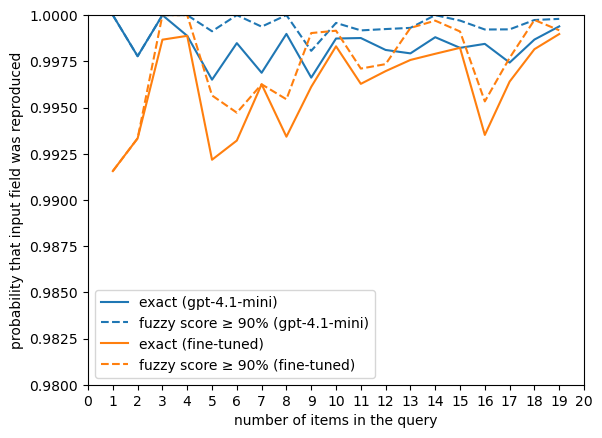

In [69]:
fig, ax = plt.subplots()

fraction100 = []
fraction90 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction100, color="tab:blue", ls="-", label="exact (gpt-4.1-mini)")
ax.plot(range(1, 20), fraction90, color="tab:blue", ls="--", label="fuzzy score ≥ 90% (gpt-4.1-mini)")

fraction100 = []
fraction90 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction100.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] == 100) / len(df_this_multiplicity))
    fraction90.append(np.count_nonzero(df_this_multiplicity["inputfuzz"] >= 90) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction100, color="tab:orange", ls="-", label="exact (fine-tuned)")
ax.plot(range(1, 20), fraction90, color="tab:orange", ls="--", label="fuzzy score ≥ 90% (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that input field was reproduced")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0.98, 1)
ax.legend()

None

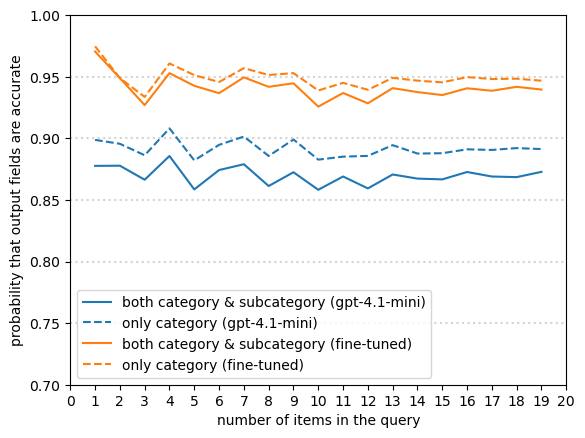

In [111]:
fig, ax = plt.subplots()

for level in np.arange(0.75, 1, 0.05):
    ax.axhline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_untuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax.plot(range(1, 20), fraction1, color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for multiplicity in range(1, 20):
    df_this_multiplicity = df_category_finetuned.query(f"multiplicity == {multiplicity}")
    fraction1.append(np.count_nonzero(df_this_multiplicity["good_category"]) / len(df_this_multiplicity))
    fraction2.append(np.count_nonzero(df_this_multiplicity["good_category"] & df_this_multiplicity["good_subcategory"]) / len(df_this_multiplicity))
ax.plot(range(1, 20), fraction2, color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax.plot(range(1, 20), fraction1, color="tab:orange", ls="--", label="only category (fine-tuned)")

ax.set_xlabel("number of items in the query")
ax.set_ylabel("probability that output fields are accurate")
ax.set_xlim(0, 20)
ax.set_xticks(range(21))
ax.set_ylim(0.7, 1)
ax.legend()

None

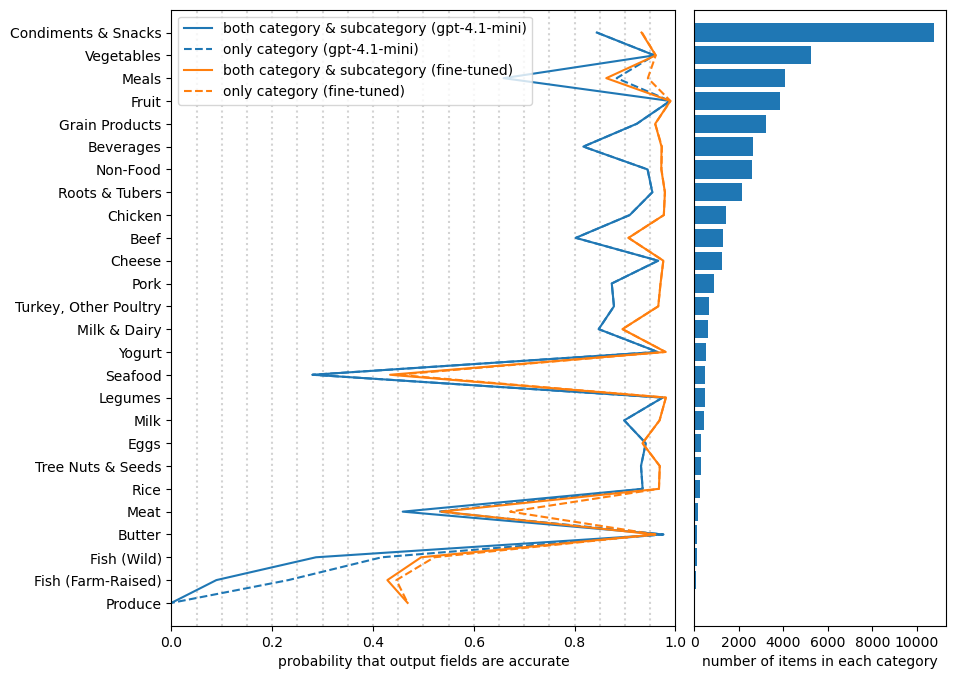

In [115]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[10, 8], gridspec_kw=dict(width_ratios=[2, 1], wspace=0.05))

category_counts = df_category_untuned["category"].value_counts().to_dict()

for level in np.arange(0.05, 1, 0.05):
    ax1.axvline(level, color="lightgrey", ls=":")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_untuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:blue", ls="-", label="both category & subcategory (gpt-4.1-mini)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:blue", ls="--", label="only category (gpt-4.1-mini)")

fraction1 = []
fraction2 = []
for category, count in category_counts.items():
    df_this_category = df_category_finetuned.query(f"category == {category!r}")
    fraction1.append(np.count_nonzero(df_this_category["good_category"]) / len(df_this_category))
    fraction2.append(np.count_nonzero(df_this_category["good_category"] & df_this_category["good_subcategory"]) / len(df_this_category))
ax1.plot(fraction2, range(len(category_counts))[::-1], color="tab:orange", ls="-", label="both category & subcategory (fine-tuned)")
ax1.plot(fraction1, range(len(category_counts))[::-1], color="tab:orange", ls="--", label="only category (fine-tuned)")

ax1.set_yticks(range(len(category_counts)), list(category_counts)[::-1])
ax1.set_xlabel("probability that output fields are accurate")
ax1.set_xlim(0, 1)
ax1.set_ylim(-1, len(category_counts))
ax1.legend(loc="upper left")

ax2.barh(range(len(category_counts)), list(category_counts.values())[::-1])

ax2.set_yticks([])
ax2.set_xlabel("number of items in each category")
ax2.set_ylim(-1, len(category_counts))

None